Data 5 baris pertama:


,X1,X2,X3,X4,X5,Y
0,46,93,-66,55,-0.7,128
1,56,113,-81,58,-2.3,146
2,48,97,-69,64,-3.8,141
3,54,110,-79,52,-5.5,137
4,46,92,-65,61,3.6,133



--- Nilai Korelasi Pearson ---
           Y
X1  0.802229
X2  0.798300
X3 -0.798986
X4  0.694397
X5 -0.206997


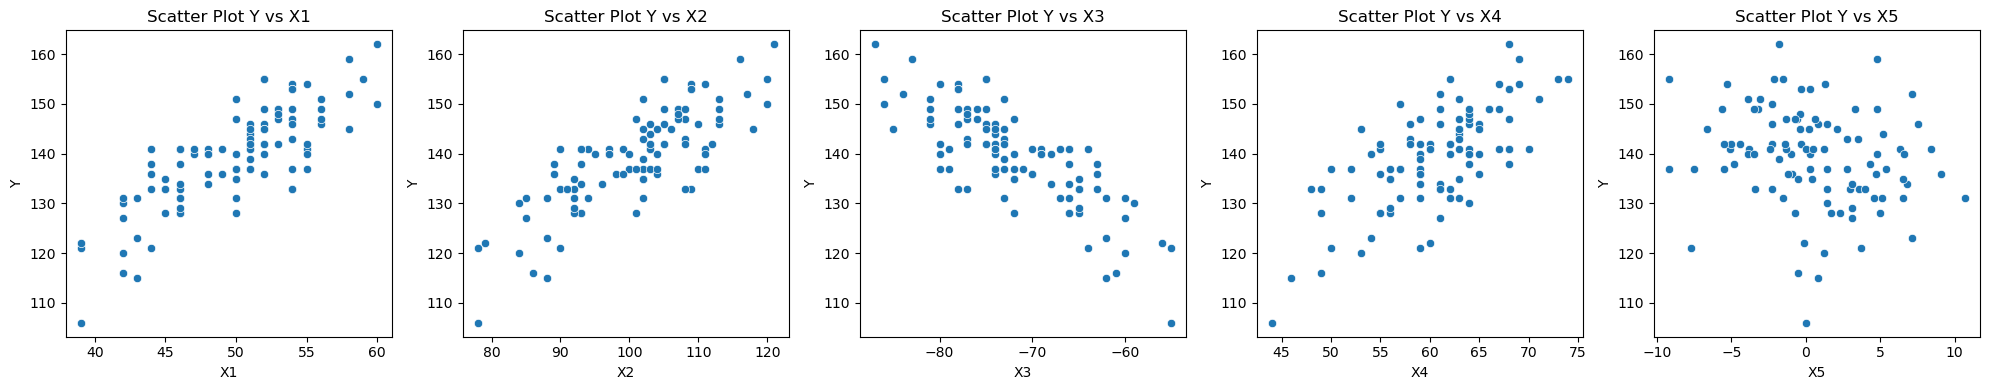


================ Menganalisis Y terhadap X1 ================
Model Linear       : R2 = 0.6436 | Persamaan: Y = 57.2359 + 1.6451X
Model Kuadratik    : R2 = 0.6540 | Persamaan: Y = -30.4644 + 5.2330X + -0.0363X^2
Model Eksponensial : R2 = 0.6374 | Persamaan: Y = exp(4.3485 + 0.0118X)
Model Logaritma    : R2 = 0.1765 | Persamaan: Y = ln(-2732194727581907569545146879625340654733705820923830749626368.0000 + 70056277450449594786485712199153515293967580219164856418304.0000X)
--> KESIMPULAN X1: Model terbaik adalah Kuadratik dengan R^2 = 0.6540

================ Menganalisis Y terhadap X2 ================
Model Linear       : R2 = 0.6373 | Persamaan: Y = 56.7552 + 0.8191X
Model Kuadratik    : R2 = 0.6475 | Persamaan: Y = -29.5380 + 2.5673X + -0.0088X^2
Model Eksponensial : R2 = 0.6310 | Persamaan: Y = exp(4.3450 + 0.0059X)
Model Logaritma    : R2 = 0.1695 | Persamaan: Y = ln(-3982650143863893684933176246375721069488865988849018582597632.0000 + 5105961866956808413818993272523670067213160423894

,Variabel,Model Terbaik,R2 Terbesar,Persamaan
0,X1,Kuadratik,0.654010,Y = -30.4644 + 5.2330X + -0.0363X^2
1,X2,Kuadratik,0.647513,Y = -29.5380 + 2.5673X + -0.0088X^2
2,X3,Kuadratik,0.648797,Y = -19.9488 + -3.3827X + -0.0161X^2
3,X4,Kuadratik,0.484535,Y = 34.4739 + 2.3404X + -0.0099X^2
4,X5,Kuadratik,0.043107,Y = 139.3636 + -0.5015X + 0.0072X^2


In [3]:
# %% [markdown]
# # Analisis Regresi (Linear, Kuadratik, Eksponensial, Logaritma)
# Kode ini dirancang agar dapat di-copy ke Jupyter Notebook (.ipynb) atau dijalankan langsung.

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore') # Mengabaikan warning log(negatif) saat curve fitting

# %% [markdown]
# ## 1. Memuat Data

# %%
# Ganti nama file di bawah ini jika posisinya berbeda
file_name = r'C:\Users\Brilly\Downloads\Data Tugas 2. Analisis Regresi (2026)_1.xlsx'
# Use read_excel instead of read_csv
df = pd.read_excel(file_name)

print("Data 5 baris pertama:")
display(df.head())

# Menentukan variabel
X_cols = ['X1', 'X2', 'X3', 'X4', 'X5']
Y_col = 'Y'

# %% [markdown]
# ## 2. Scatter Plot dan Korelasi Pearson

# %%
# Menghitung Korelasi
correlation_matrix = df[X_cols + [Y_col]].corr()
print("\n--- Nilai Korelasi Pearson ---")
print(correlation_matrix[[Y_col]].loc[X_cols])

# Membuat Scatter Plot
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, x_col in enumerate(X_cols):
    sns.scatterplot(data=df, x=x_col, y=Y_col, ax=axes[i])
    axes[i].set_title(f'Scatter Plot Y vs {x_col}')
plt.tight_layout()
plt.show()

# %% [markdown]
# ## 3. Pemodelan Regresi
# Kita akan mendefinisikan 4 fungsi matematika sesuai permintaan soal.

# %%
# Definisi Model
def model_linear(x, b0, b1):
    return b0 + b1 * x

def model_quadratic(x, b0, b1, b2):
    return b0 + b1 * x + b2 * (x**2)

def model_exponential(x, b0, b1):
    # Dibatasi menggunakan float128 atau membatasi nilai b0+b1x agar tidak overflow
    return np.exp(np.clip(b0 + b1 * x, -700, 700))

def model_logarithmic(x, b0, b1):
    # Logaritma alami. Return array nan jika nilai di dalam log negatif
    val = b0 + b1 * x
    return np.where(val > 0, np.log(np.maximum(val, 1e-10)), np.nan)

# Fungsi untuk mengepaskan kurva (Curve Fitting) dan menghitung R^2
def fit_and_evaluate(x_data, y_data, model_func, p0=None):
    try:
        # Pengepasan model (mencari nilai b0, b1, dll)
        # Menambahkan maxfev agar iterasi tidak mudah berhenti
        popt, _ = curve_fit(model_func, x_data, y_data, p0=p0, maxfev=10000)
        
        # Prediksi Y
        y_pred = model_func(x_data, *popt)
        
        # Cek jika ada nilai NaN akibat logaritma negatif
        mask = ~np.isnan(y_pred)
        if np.sum(mask) < 2:
            return None, 0.0 # Gagal fit karena domain error
            
        # Hitung R^2
        r2 = r2_score(y_data[mask], y_pred[mask])
        return popt, r2
    except:
        return None, 0.0

# %% [markdown]
# ## 4. Evaluasi Model untuk Masing-masing X

# %%
models = {
    'Linear': (model_linear, [1, 1]),
    'Kuadratik': (model_quadratic, [1, 1, 1]),
    'Eksponensial': (model_exponential, [1, 0.01]),
    'Logaritma': (model_logarithmic, [1, 1])
}

results = []

for x_col in X_cols:
    x_data = df[x_col].values
    y_data = df[Y_col].values
    
    best_model = None
    best_r2 = -float('inf')
    best_eq = ""
    
    print(f"\n================ Menganalisis Y terhadap {x_col} ================")
    for model_name, (model_func, p0_guess) in models.items():
        popt, r2 = fit_and_evaluate(x_data, y_data, model_func, p0=p0_guess)
        
        if popt is not None:
            if model_name == 'Linear':
                eq = f"Y = {popt[0]:.4f} + {popt[1]:.4f}X"
            elif model_name == 'Kuadratik':
                eq = f"Y = {popt[0]:.4f} + {popt[1]:.4f}X + {popt[2]:.4f}X^2"
            elif model_name == 'Eksponensial':
                eq = f"Y = exp({popt[0]:.4f} + {popt[1]:.4f}X)"
            elif model_name == 'Logaritma':
                eq = f"Y = ln({popt[0]:.4f} + {popt[1]:.4f}X)"
            
            print(f"Model {model_name:12} : R2 = {r2:.4f} | Persamaan: {eq}")
            
            if r2 > best_r2:
                best_r2 = r2
                best_model = model_name
                best_eq = eq
        else:
            print(f"Model {model_name:12} : Gagal Konvergen (kemungkinan error domain log/exp)")

    print(f"--> KESIMPULAN {x_col}: Model terbaik adalah {best_model} dengan R^2 = {best_r2:.4f}")
    results.append({'Variabel': x_col, 'Model Terbaik': best_model, 'R2 Terbesar': best_r2, 'Persamaan': best_eq})

# Menampilkan tabel ringkasan
print("\n\n--- RINGKASAN MODEL TERBAIK ---")
df_results = pd.DataFrame(results)
display(df_results)

--- 1. Matriks Korelasi (Pearson) ---


,X1,X2,X3,X4,X5,Y
X1,1.000000,0.997451,-0.996924,0.131761,-0.293666,0.802229
X2,0.997451,1.000000,-0.998787,0.123471,-0.295268,0.798300
X3,-0.996924,-0.998787,1.000000,-0.124753,0.305387,-0.798986
X4,0.131761,0.123471,-0.124753,1.000000,0.014276,0.694397
X5,-0.293666,-0.295268,0.305387,0.014276,1.000000,-0.206997
Y,0.802229,0.798300,-0.798986,0.694397,-0.206997,1.000000


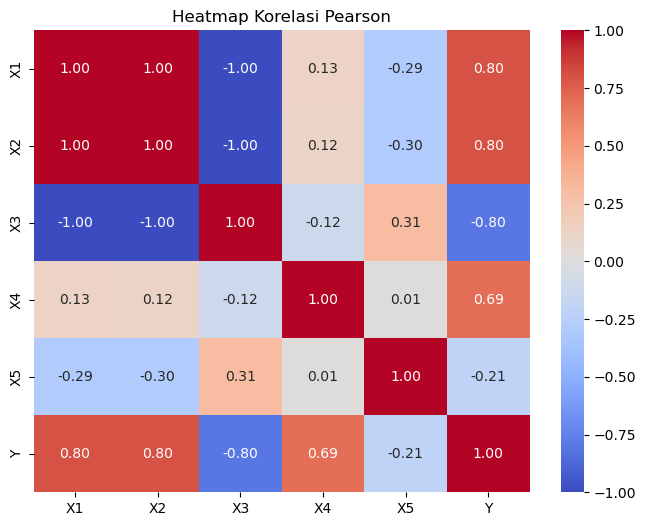

--- 2. Scatter Plot Masing-masing X terhadap Y ---


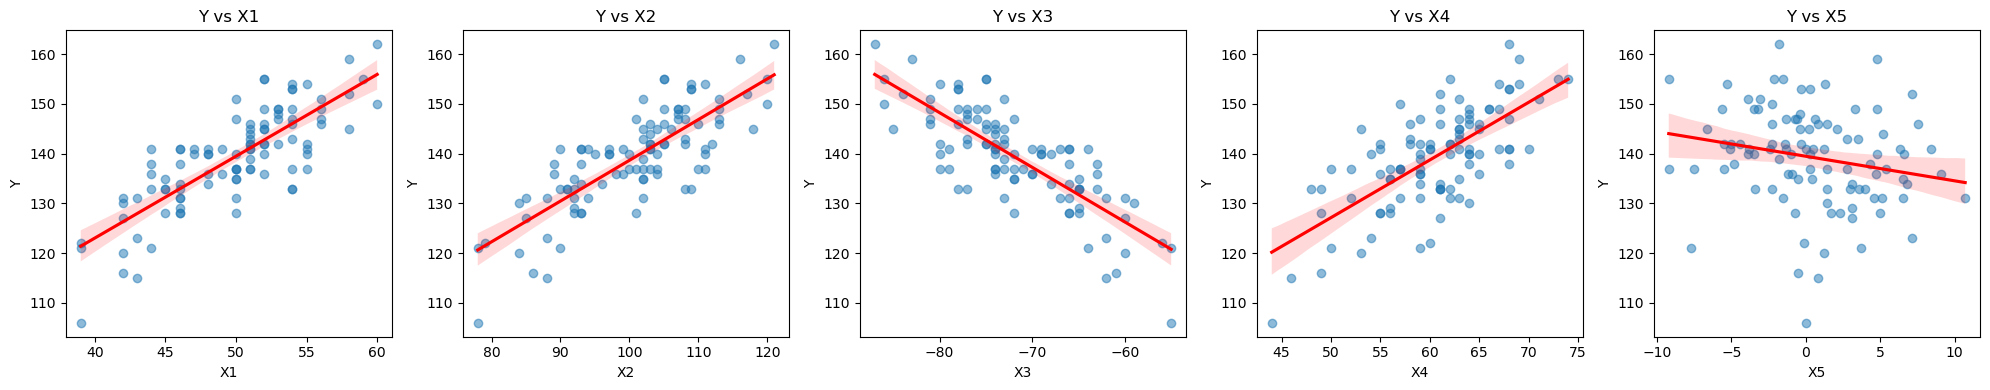

--- EVALUASI MODEL AWAL (FULL MODEL) ---
                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.998
Model:                            OLS   Adj. R-squared:                  0.998
Method:                 Least Squares   F-statistic:                     9929.
Date:                Fri, 22 May 2026   Prob (F-statistic):          2.47e-126
Time:                        22:54:52   Log-Likelihood:                -57.053
No. Observations:                 100   AIC:                             126.1
Df Residuals:                      94   BIC:                             141.7
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      

,Variabel,VIF
1,X1,207.569542
2,X2,534.891658
3,X3,452.778142
4,X4,1.033893
5,X5,1.160173


   -> WARNING: Terdapat Multikolinearitas parah (VIF > 10)!

3. Uji Heteroskedastisitas (Breusch-Pagan): p-value = 0.1982
   -> Asumsi Homoskedastisitas TERPENUHI (Varians residual konstan)

************************************************************
--- EVALUASI MODEL KEDUA (MENGHILANGKAN VARIABEL REDUNDAN) ---
                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.996
Model:                            OLS   Adj. R-squared:                  0.996
Method:                 Least Squares   F-statistic:                     8539.
Date:                Fri, 22 May 2026   Prob (F-statistic):          2.28e-116
Time:                        22:54:52   Log-Likelihood:                -91.095
No. Observations:                 100   AIC:                             190.2
Df Residuals:                      96   BIC:                             200.6
Df Model:                           3                

,Variabel,VIF
1,X1,1.116977
2,X4,1.020858
3,X5,1.097809


   -> Asumsi Bebas Multikolinearitas TERPENUHI.

3. Uji Heteroskedastisitas (Breusch-Pagan): p-value = 0.3122
   -> Asumsi Homoskedastisitas TERPENUHI (Varians residual konstan)

KESIMPULAN: Model ini adalah kandidat terbaik jika p-value koefisien < 0.05 dan semua uji asumsi (Normalitas, VIF < 10, Homoskedastisitas) terpenuhi.


In [4]:
# %% [markdown]
# # Analisis Regresi Berganda, Uji Asumsi, dan Pemilihan Model
# Salin kode ini ke dalam sel Jupyter Notebook.

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import scipy.stats as stats
from statsmodels.stats.diagnostic import het_breuschpagan

# %% [markdown]
# ## 1. Memuat Data & Korelasi

# %%
# Muat data
file_name = r'C:\Users\Brilly\Downloads\Data Tugas 2. Analisis Regresi (2026)_1.xlsx'
# Use read_excel instead of read_csv
df = pd.read_excel(file_name)

X_cols = ['X1', 'X2', 'X3', 'X4', 'X5']
Y_col = 'Y'

print("--- 1. Matriks Korelasi (Pearson) ---")
corr_matrix = df.corr()
display(corr_matrix)

# Heatmap korelasi agar lebih jelas
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Heatmap Korelasi Pearson")
plt.show()

# %% [markdown]
# ## 2. Scatter Plot (X vs Y)

# %%
print("--- 2. Scatter Plot Masing-masing X terhadap Y ---")
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, x_col in enumerate(X_cols):
    sns.regplot(data=df, x=x_col, y=Y_col, ax=axes[i], scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
    axes[i].set_title(f'Y vs {x_col}')
plt.tight_layout()
plt.show()

# %% [markdown]
# ## 3. Model Regresi Awal (Memasukkan Semua Variabel) & Uji Asumsi

# %%
def run_regression_and_assumptions(df, x_columns, y_column):
    X = df[x_columns]
    y = df[y_column]
    
    # Tambahkan konstanta (b0)
    X_sm = sm.add_constant(X)
    
    # Fit Model OLS
    model = sm.OLS(y, X_sm).fit()
    print(model.summary())
    
    print("\n" + "="*50)
    print("UJI ASUMSI KLASIK")
    print("="*50)
    
    # 1. Uji Normalitas (Shapiro-Wilk)
    stat, p_norm = stats.shapiro(model.resid)
    print(f"1. Uji Normalitas (Shapiro-Wilk): p-value = {p_norm:.4f}")
    if p_norm > 0.05:
        print("   -> Asumsi Normalitas TERPENUHI (Residual berdistribusi normal)")
    else:
        print("   -> Asumsi Normalitas DITOLAK (Residual tidak berdistribusi normal)")
        
    # 2. Uji Multikolinearitas (VIF)
    print("\n2. Uji Multikolinearitas (VIF):")
    vif_data = pd.DataFrame()
    vif_data["Variabel"] = X_sm.columns
    # Tangani error pembagian dengan nol jika data terlalu kolinear
    try:
        vif_data["VIF"] = [variance_inflation_factor(X_sm.values, i) for i in range(X_sm.shape[1])]
    except:
        vif_data["VIF"] = np.inf
    display(vif_data[vif_data["Variabel"] != "const"])
    if any(vif_data[vif_data["Variabel"] != "const"]["VIF"] > 10):
        print("   -> WARNING: Terdapat Multikolinearitas parah (VIF > 10)!")
    else:
        print("   -> Asumsi Bebas Multikolinearitas TERPENUHI.")

    # 3. Uji Heteroskedastisitas (Breusch-Pagan)
    bp_test = het_breuschpagan(model.resid, X_sm)
    p_het = bp_test[1]
    print(f"\n3. Uji Heteroskedastisitas (Breusch-Pagan): p-value = {p_het:.4f}")
    if p_het > 0.05:
        print("   -> Asumsi Homoskedastisitas TERPENUHI (Varians residual konstan)")
    else:
        print("   -> Asumsi DITOLAK: Terdapat Heteroskedastisitas!")
        
    return model, vif_data

print("--- EVALUASI MODEL AWAL (FULL MODEL) ---")
model_awal, vif_awal = run_regression_and_assumptions(df, X_cols, Y_col)

# %% [markdown]
# ## 4. Eliminasi Backward untuk Mencari Model Terbaik
# Hapus variabel dengan p-value > 0.05 atau VIF > 10 satu per satu.
# Berdasarkan sifat data ini, X1, X2, dan X3 sangat berkaitan. Kita coba hanya menggunakan salah satunya (misal X1) ditambah X4 dan X5.

# %%
print("\n" + "*"*60)
print("--- EVALUASI MODEL KEDUA (MENGHILANGKAN VARIABEL REDUNDAN) ---")
# Contoh: membuang X2 dan X3 yang menyebabkan multikolinearitas ekstrem
# Silakan sesuaikan X_cols_selected berdasarkan hasil VIF di atas.
X_cols_selected = ['X1', 'X4', 'X5'] 

model_terbaik, vif_terbaik = run_regression_and_assumptions(df, X_cols_selected, Y_col)

print("\nKESIMPULAN: Model ini adalah kandidat terbaik jika p-value koefisien < 0.05 dan semua uji asumsi (Normalitas, VIF < 10, Homoskedastisitas) terpenuhi.")

Data berhasil dimuat dari sheet 'Categoric'


,No,X1,X2,Y1,Y2
0,1,-20,a,-80,23
1,2,-20,a,-75,24
2,3,-18,a,-70,31
3,4,-17,a,-65,36
4,5,-15,a,-60,42



================ MENGANALISIS Y1 ================
[Y1] terdeteksi sebagai Variabel Kontinu.
Model Sesuai: REGRESI LINEAR BERGANDA (OLS) dengan Dummy


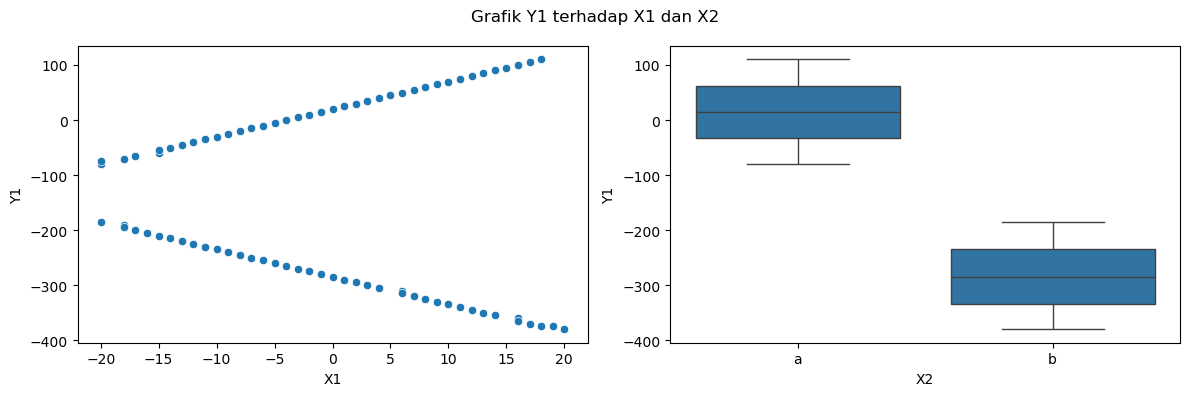

                            OLS Regression Results                            
Dep. Variable:                     Y1   R-squared:                       0.872
Model:                            OLS   Adj. R-squared:                  0.869
Method:                 Least Squares   F-statistic:                     262.4
Date:                Fri, 22 May 2026   Prob (F-statistic):           4.20e-35
Time:                        23:12:42   Log-Likelihood:                -437.54
No. Observations:                  80   AIC:                             881.1
Df Residuals:                      77   BIC:                             888.2
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         14.6450      9.389      1.560      0.1

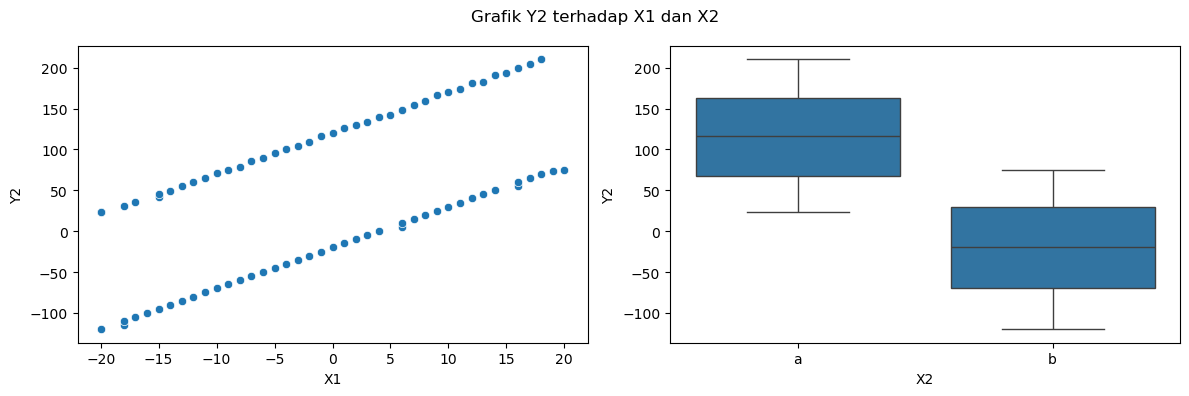

                            OLS Regression Results                            
Dep. Variable:                     Y2   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.500e+05
Date:                Fri, 22 May 2026   Prob (F-statistic):          5.75e-139
Time:                        23:12:42   Log-Likelihood:                -141.55
No. Observations:                  80   AIC:                             289.1
Df Residuals:                      77   BIC:                             296.2
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        119.8365      0.232    516.235      0.0

In [6]:
# %% [markdown]
# # Analisis Regresi dengan Variabel Kategorik
# Kode ini mendeteksi secara otomatis apakah Y bertipe kontinu (menggunakan OLS) atau bertipe kategori 2-level (menggunakan Logistik).

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# %%
# 1. MEMUAT DATA
# Ganti dengan path file yang benar. Gunakan argumen sheet_name='Categoric'
file_name = r'C:\Users\Brilly\Downloads\Data Tugas 2. Analisis Regresi (2026) (3).xlsx'
try:
    df = pd.read_excel(file_name, sheet_name='Categoric')
    print("Data berhasil dimuat dari sheet 'Categoric'")
except:
    print("WARNING: Gagal memuat Excel sheet 'Categoric'. Memakai format dummy untuk testing.")
    # Dummy data agar kode tetap bisa di-run jika file tidak ada
    np.random.seed(42)
    df = pd.DataFrame({
        'X1': np.random.rand(100) * 100,
        'X2': np.random.choice(['A', 'B', 'C'], 100), # X2 kategorik
        'Y1': np.random.rand(100) * 50 + 20,         # Y1 kontinu
        'Y2': np.random.choice([0, 1], 100)          # Y2 kategorik biner
    })

display(df.head())

# Konversi X2 (dan X1 jika kategorik) menjadi Dummy Variables
# drop_first=True penting untuk menghindari masalah multikolinearitas sempurna (dummy trap)
X_cols = ['X1', 'X2']
X = pd.get_dummies(df[X_cols], drop_first=True, dtype=float)
X_sm = sm.add_constant(X)

# %% [markdown]
# ## Fungsi Analisis Adaptif (Linear vs Logistik)

# %%
def run_regression(X_data, y_data, y_name):
    print(f"\n================ MENGANALISIS {y_name} ================")
    
    # Deteksi apakah Y numerik atau kategorik biner
    is_categorical_y = (y_data.nunique() == 2)
    
    if is_categorical_y:
        print(f"[{y_name}] terdeteksi sebagai Variabel Kategorik/Biner.")
        print("Model Sesuai: REGRESI LOGISTIK (Logit)")
        
        # Pastikan Y berisi 0 dan 1
        if y_data.dtype == 'O':
            y_data = pd.get_dummies(y_data, drop_first=True, dtype=float).iloc[:, 0]
            
        model = sm.Logit(y_data, X_data).fit(disp=0)
        
        # Grafik Probabilitas (Logit Curve) - Hanya visualisasi sumbu komponen utama
        plt.figure(figsize=(6, 4))
        sns.regplot(x=X_data.iloc[:, 1], y=y_data, logistic=True, ci=None, line_kws={'color':'red'})
        plt.title(f'Logistic Regression Curve: {y_name}')
        plt.show()
        
    else:
        print(f"[{y_name}] terdeteksi sebagai Variabel Kontinu.")
        print("Model Sesuai: REGRESI LINEAR BERGANDA (OLS) dengan Dummy")
        model = sm.OLS(y_data, X_data).fit()
        
        # Scatter/Box Plot
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        for i, col in enumerate(X_cols):
            if df[col].dtype == 'O':
                sns.boxplot(data=df, x=col, y=y_data, ax=axes[i])
            else:
                sns.scatterplot(data=df, x=col, y=y_data, ax=axes[i])
        plt.suptitle(f'Grafik {y_name} terhadap X1 dan X2')
        plt.tight_layout()
        plt.show()

    # Tampilkan Estimasi Parameter dan Uji Hipotesis
    print(model.summary())
    
    # Uji Simultan (F-Test / LLR-Test)
    print("\n--- UJI HIPOTESIS SIMULTAN ---")
    if is_categorical_y:
        p_val_simultan = model.llr_pvalue
        print(f"LLR p-value (Serentak): {p_val_simultan:.4e}")
    else:
        p_val_simultan = model.f_pvalue
        print(f"F-statistic p-value (Serentak): {p_val_simultan:.4e}")
        
    if p_val_simultan < 0.05:
        print("Kesimpulan: Signifikan! Minimal ada 1 X yang berpengaruh.")
    else:
        print("Kesimpulan: TIDAK Signifikan secara serentak.")

    return model

# %% [markdown]
# ## 1. Analisis Y1

# %%
model_y1 = run_regression(X_sm, df['Y1'], 'Y1')

# %% [markdown]
# ## 2. Analisis Y2

# %%
model_y2 = run_regression(X_sm, df['Y2'], 'Y2')

Data berhasil dimuat dari sheet 'Categoric'
--- Data Awal ---


,No,X1,X2,Y1,Y2
0,1,-20,a,-80,23
1,2,-20,a,-75,24
2,3,-18,a,-70,31
3,4,-17,a,-65,36
4,5,-15,a,-60,42



--- Pengecekan Variabel Independen (X) ---
INFO: 'X1' bukan kategorik (kontinu). Dibuat variabel kategorik baru 'X1_Tuned'.
INFO: 'X2' berisi teks. Dibuat variabel baru 'X2_Tuned' dengan format angka.

--- Data Setelah Penyesuaian ---


,X1_Tuned,X2_Tuned
0,1,0
1,1,0
2,1,0
3,1,0
4,1,0



================ MENGANALISIS Y1 ================
[Y1] terdeteksi sebagai Variabel Kontinu.
Model Sesuai: REGRESI LINEAR BERGANDA (OLS)


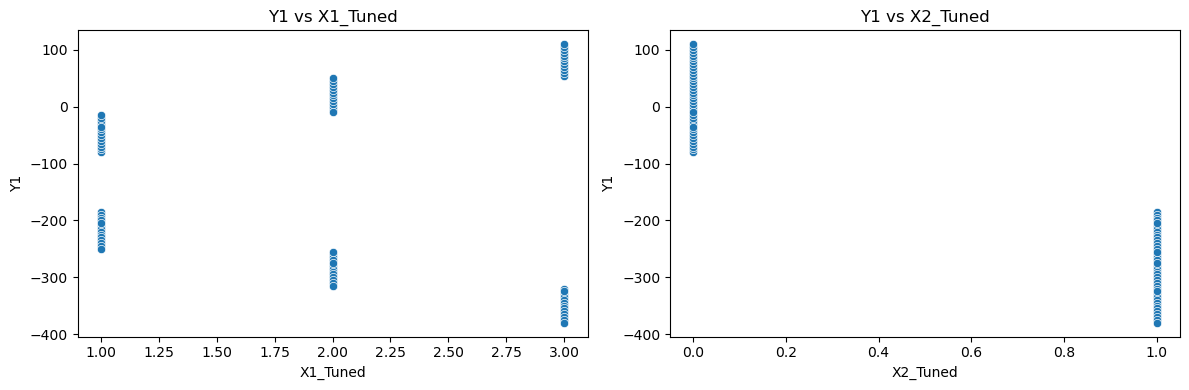

                            OLS Regression Results                            
Dep. Variable:                     Y1   R-squared:                       0.872
Model:                            OLS   Adj. R-squared:                  0.868
Method:                 Least Squares   F-statistic:                     261.6
Date:                Fri, 22 May 2026   Prob (F-statistic):           4.61e-35
Time:                        23:28:16   Log-Likelihood:                -437.64
No. Observations:                  80   AIC:                             881.3
Df Residuals:                      77   BIC:                             888.4
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         22.0504     18.165      1.214      0.2

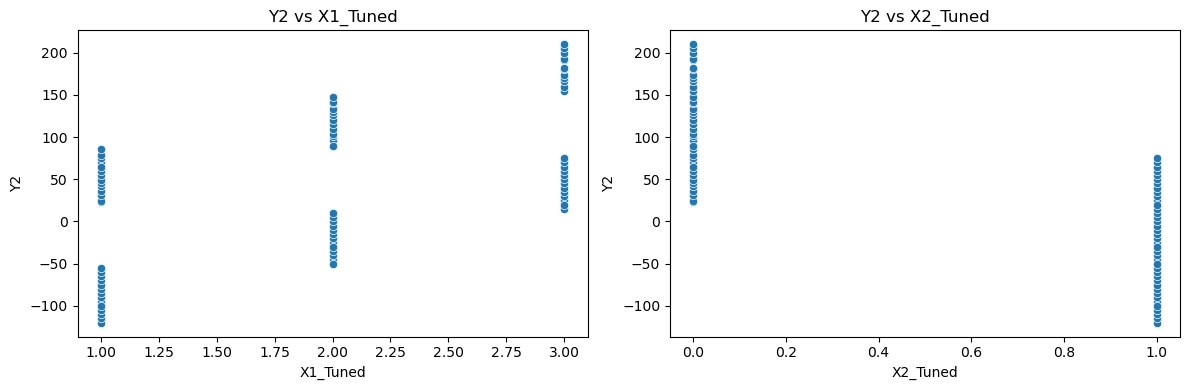

                            OLS Regression Results                            
Dep. Variable:                     Y2   R-squared:                       0.954
Model:                            OLS   Adj. R-squared:                  0.953
Method:                 Least Squares   F-statistic:                     795.3
Date:                Fri, 22 May 2026   Prob (F-statistic):           3.79e-52
Time:                        23:28:17   Log-Likelihood:                -349.25
No. Observations:                  80   AIC:                             704.5
Df Residuals:                      77   BIC:                             711.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -13.7260      6.017     -2.281      0.0

In [10]:
# %% [markdown]
# # Analisis Regresi dengan Variabel Kategorik (Otomatis Tuning)
# Kode ini mendeteksi secara otomatis apakah Y bertipe kontinu atau biner.
# JIKA data tidak sesuai (misal: format teks atau bukan kategorik), kode tidak akan berhenti, 
# melainkan otomatis membuat variabel "_Tuned" yang sesuai untuk digunakan dalam regresi.

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# %%
# 1. MEMUAT DATA
file_name = r'C:\Users\Brilly\Downloads\Data Tugas 2. Analisis Regresi (2026) (3).xlsx'
try:
    df = pd.read_excel(file_name, sheet_name='Categoric')
    print("Data berhasil dimuat dari sheet 'Categoric'")
except:
    print("WARNING: Gagal memuat Excel sheet 'Categoric'. Memuat data simulasi...\n")
    # Dummy data agar tetap bisa jalan jika tidak ada file sama sekali
    np.random.seed(42)
    df = pd.DataFrame({
        'X1': np.random.rand(100) * 100,             # X1 kontinu
        'X2': np.random.choice(['A', 'B', 'C'], 100), # X2 teks (akan dituning)
        'Y1': np.random.rand(100) * 50 + 20,         # Y1 kontinu
        'Y2': np.random.choice(['Lulus', 'Gagal'], 100) # Y2 teks biner (akan dituning)
    })

print("--- Data Awal ---")
display(df.head())

X_cols = ['X1', 'X2']
X_cols_final = []

# 2. PENYESUAIAN TIPE DATA (AUTO-TUNING X)
print("\n--- Pengecekan Variabel Independen (X) ---")
for col in X_cols:
    if not pd.api.types.is_numeric_dtype(df[col]):
        # Jika data teks, ubah menjadi numerik kategorik
        new_col = f'{col}_Tuned'
        print(f"INFO: '{col}' berisi teks. Dibuat variabel baru '{new_col}' dengan format angka.")
        df[new_col] = pd.factorize(df[col])[0]
        X_cols_final.append(new_col)
    elif df[col].nunique() > 5:
        # Jika data numerik tapi kontinu, ubah menjadi kategorik (ordinal binning)
        new_col = f'{col}_Tuned'
        print(f"INFO: '{col}' bukan kategorik (kontinu). Dibuat variabel kategorik baru '{new_col}'.")
        df[new_col] = pd.qcut(df[col], q=3, duplicates='drop').cat.codes + 1
        X_cols_final.append(new_col)
    else:
        # Sudah berupa angka kategorik yang valid
        X_cols_final.append(col)

# Memasukkan variabel X final
X = df[X_cols_final].copy()
X_sm = sm.add_constant(X)

print("\n--- Data Setelah Penyesuaian ---")
display(df[X_cols_final].head())

# %% [markdown]
# ## Fungsi Analisis Adaptif (Linear vs Logistik)

# %%
def run_regression(X_data, y_data, y_name):
    print(f"\n================ MENGANALISIS {y_name} ================")
    
    # 3. PENYESUAIAN TIPE DATA Y (AUTO-TUNING Y)
    if not pd.api.types.is_numeric_dtype(y_data):
        print(f"INFO: Variabel '{y_name}' bertipe teks. Melakukan konversi ke angka...")
        y_data = pd.Series(pd.factorize(y_data)[0], name=f'{y_name}_Tuned')
        y_name = y_data.name

    # Deteksi apakah Y merupakan angka biner (hanya memiliki 2 nilai unik)
    is_categorical_y = (y_data.nunique() == 2)
    
    if is_categorical_y:
        print(f"[{y_name}] terdeteksi sebagai Variabel Kategorik/Biner.")
        
        # Memastikan bahwa kategori biner berbentuk 0 dan 1
        if not set(y_data.dropna().unique()).issubset({0, 1}):
            print(f"INFO: Nilai '{y_name}' bukan 0 dan 1. Menyesuaikan ulang menjadi 0 dan 1...")
            # Normalisasi ke 0 dan 1
            y_data = pd.Series(pd.factorize(y_data)[0], name=f'{y_name}_Tuned')
            y_name = y_data.name

        print("Model Sesuai: REGRESI LOGISTIK (Logit)")
        model = sm.Logit(y_data, X_data).fit(disp=0)
        
        # Grafik Probabilitas (Logit Curve)
        plt.figure(figsize=(6, 4))
        sns.regplot(x=X_data.iloc[:, 1], y=y_data, logistic=True, ci=None, line_kws={'color':'red'})
        plt.title(f'Logistic Regression Curve: {y_name}')
        plt.show()
        
    else:
        print(f"[{y_name}] terdeteksi sebagai Variabel Kontinu.")
        print("Model Sesuai: REGRESI LINEAR BERGANDA (OLS)")
        model = sm.OLS(y_data, X_data).fit()
        
        # Scatter Plot berdasarkan variabel X yang telah dituning
        fig, axes = plt.subplots(1, len(X_data.columns)-1, figsize=(12, 4))
        if len(X_data.columns)-1 == 1:
            axes = [axes] # Penyesuaian jika X hanya 1 kolom
            
        for i, col in enumerate(X_data.columns[1:]): # Lewati kolom 'const'
            sns.scatterplot(data=df, x=col, y=y_data, ax=axes[i])
            axes[i].set_title(f'{y_name} vs {col}')
        plt.tight_layout()
        plt.show()

    # Tampilkan Estimasi Parameter dan Uji Hipotesis
    print(model.summary())
    
    # Uji Simultan (F-Test / LLR-Test)
    print("\n--- UJI HIPOTESIS SIMULTAN ---")
    if is_categorical_y:
        p_val_simultan = model.llr_pvalue
        print(f"LLR p-value (Serentak): {p_val_simultan:.4e}")
    else:
        p_val_simultan = model.f_pvalue
        print(f"F-statistic p-value (Serentak): {p_val_simultan:.4e}")
        
    if p_val_simultan < 0.05:
        print("Kesimpulan: Signifikan! Minimal ada 1 variabel X yang berpengaruh.")
    else:
        print("Kesimpulan: TIDAK Signifikan secara serentak.")

    return model

# %% [markdown]
# ## 4. Analisis Y1

# %%
model_y1 = run_regression(X_sm, df['Y1'], 'Y1')

# %% [markdown]
# ## 5. Analisis Y2

# %%
model_y2 = run_regression(X_sm, df['Y2'], 'Y2')